## Building a CNN to classify images in the CIFAR-10 Dataset

We will work with the CIFAR-10 Dataset.  This is a well-known dataset for image classification, which consists of 60000 32x32 color images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images.

The 10 classes are:

<ol start="0">
<li> airplane
<li>  automobile
<li> bird
<li>  cat
<li> deer
<li> dog
<li>  frog
<li>  horse
<li>  ship
<li>  truck
</ol>

For details about CIFAR-10 see:
https://www.cs.toronto.edu/~kriz/cifar.html

For a compilation of published performance results on CIFAR 10, see:
http://rodrigob.github.io/are_we_there_yet/build/classification_datasets_results.html

---

### Building Convolutional Neural Nets

In this exercise we will build and train our first convolutional neural networks.  In the first part, we walk through the different layers and how they are configured.  In the second part, you will build your own model, train it, and compare the performance.

In [5]:
import keras
import tensorflow as tf
from keras.datasets import cifar10
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Conv2D, MaxPooling2D

import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
# tensorflow version
print(tf.__version__)

2.19.0


In [7]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available: 0


In [8]:
# The data, shuffled and split between train and test sets:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print('x_train shape:', x_train.shape)
print('x_train shape:', y_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

x_train shape: (50000, 32, 32, 3)
x_train shape: (50000, 1)
50000 train samples
10000 test samples


In [9]:
## Each image is a 32 x 32 x 3 numpy array
x_train[444].shape

(32, 32, 3)

[9]


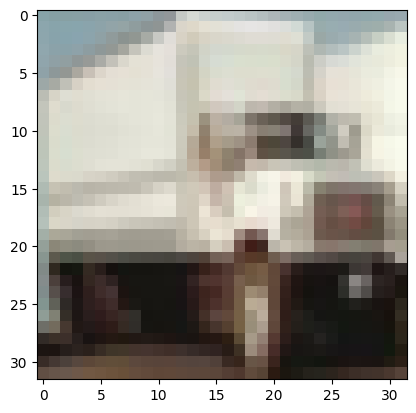

In [10]:
## Let's look at one of the images

print(y_train[444])
plt.imshow(x_train[444])
plt.show()

In [11]:
num_classes = 10

y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

In [12]:
# now instead of classes described by an integer between 0-9 we have a vector with a 1 in the (Pythonic) 9th position
y_train[444]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

In [13]:
# As before, let's make everything float and scale
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255

## Keras Layers for CNNs
- Previously we built Neural Networks using primarily the Dense, Activation and Dropout Layers.

- Here we will describe how to use some of the CNN-specific layers provided by Keras

### Conv2D
   <img src="conv_equa.PNG"/>
   
```python
keras.layers.convolutional.Conv2D(filters, kernel_size, strides=(1, 1), padding='valid', data_format=None, dilation_rate=(1, 1), activation=None, use_bias=True, kernel_initializer='glorot_uniform', bias_initializer='zeros', kernel_regularizer=None, bias_regularizer=None, activity_regularizer=None, kernel_constraint=None, bias_constraint=None, **kwargs)
```

A few parameters explained:
- `filters`: the number of filter used per location.  In other words, the depth of the output.
- `kernel_size`: an (x,y) tuple giving the height and width of the kernel to be used
- `strides`: and (x,y) tuple giving the stride in each dimension.  Default is `(1,1)`
- `input_shape`: required only for the first layer

Note, the size of the output will be determined by the kernel_size, strides

### MaxPooling2D
`keras.layers.pooling.MaxPooling2D(pool_size=(2, 2), strides=None, padding='valid', data_format=None)`

- `pool_size`: the (x,y) size of the grid to be pooled.
- `strides`: Assumed to be the `pool_size` unless otherwise specified

The resulting output when using the "valid" padding option has a spatial shape (number of rows or columns) of: output_shape = math.floor((input_shape - pool_size) / strides) + 1 (when input_shape >= pool_size)

The resulting output shape when using the "same" padding option is: output_shape = math.floor((input_shape - 1) / strides) + 1
### Flatten
Turns its input into a one-dimensional vector (per instance).  Usually used when transitioning between convolutional layers and fully connected layers.

---

## First CNN
Below we will build our first CNN.  For demonstration purposes (so that it will train quickly) it is not very deep and has relatively few parameters.  We use strides of 2 in the first two convolutional layers which quickly reduces the dimensions of the output.  After a MaxPooling layer, we flatten, and then have a single fully connected layer before our final classification layer.

In [14]:
# Let's build a CNN using Keras' Sequential capabilities

model_1 = Sequential()


## 5x5 convolution with 2x2 stride and 32 filters
model_1.add(Conv2D(32, kernel_size = (5, 5), strides = (2,2), padding='same',
                 input_shape=x_train.shape[1:]))
model_1.add(Activation('relu'))

## Another 5x5 convolution with 2x2 stride and 32 filters
model_1.add(Conv2D(32, (5, 5), strides = (2,2), activation="relu")) # another way to define activation


## 2x2 max pooling reduces to 3 x 3 x 32
model_1.add(MaxPooling2D(pool_size=(2, 2)))
model_1.add(Dropout(0.25))

## Flatten turns 3x3x32 into 288x1
model_1.add(Flatten())
model_1.add(Dense(512))
model_1.add(Activation('relu'))
model_1.add(Dropout(0.5))
model_1.add(Dense(num_classes))
model_1.add(Activation('softmax'))

model_1.summary()

c:\Users\saadd\anaconda3\envs\gsoc-aeon\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 16, 16, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 6, 6, 32)       │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       147,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 181,162 (707.66 KB)

 Trainable params: 181,162 (707.66 KB)

 Non-trainable params: 0 (0.00 B)

We still have 181K parameters, even though this is a "small" model.


In [15]:
batch_size = 32

# initiate RMSprop optimizer
opt = keras.optimizers.RMSprop(learning_rate=0.0005)

# Let's train the model using RMSprop
model_1.compile(loss='categorical_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])

model_1.fit(x_train, y_train,
              batch_size=batch_size,
              epochs=15,
              validation_data=(x_test, y_test),
              shuffle=True)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.3037 - loss: 1.8938 - val_accuracy: 0.4878 - val_loss: 1.4200
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.4702 - loss: 1.4650 - val_accuracy: 0.4917 - val_loss: 1.4074
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.5151 - loss: 1.3607 - val_accuracy: 0.5514 - val_loss: 1.2542
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.5388 - loss: 1.3129 - val_accuracy: 0.5289 - val_loss: 1.3450
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.5570 - loss: 1.2719 - val_accuracy: 0.5592 - val_loss: 1.2568
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.5628 - loss: 1.2616 - val_accuracy: 0.5576 - val_loss: 1.3136
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.5652 - loss: 1.2453 - val_accuracy: 0.5453 - val_loss: 1.3012
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.5766 - loss: 

### Exercise
Our previous model had the structure:

Conv -> Conv -> MaxPool -> (Flatten) -> Dense -> Final Classification

(with appropriate activation functions and dropouts)

1. Build a more complicated model with the following pattern:
- Conv -> Conv -> MaxPool -> Conv -> Conv -> MaxPool -> (Flatten) -> Dense -> Final Classification

- Use strides of 1 for all convolutional layers.

2. How many parameters does your model have?  How does that compare to the previous model?

3. Train it for 5 epochs.  What do you notice about the training time, loss and accuracy numbers (on both the training and validation sets)?

5. Try different structures and run times, and see how accurate your model can be.


In [ ]:
# Please provide your solution here
# Create model_2 as mentioned in the exercise

model_2 = Sequential(
    [
        Conv2D(32,kernel_size=(3,3), padding="same", activation="relu", input_shape=x_train.shape[1:]),
        Conv2D(32, kernel_size=(3,3), padding="same", activation="relu"),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        Conv2D(128, kernel_size=(3,3), padding="same", activation="relu"),
        Conv2D(256, kernel_size=(3,3), padding="same", activation="relu"),
        MaxPooling2D(pool_size=(2, 2)), 
        Dropout(0.25),
        Flatten(),
        Dense(512, activation="relu"),
        Dense(num_classes, activation="softmax"),
    ]
)

model_2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,782,666 (33.50 MB)

 Trainable params: 8,782,666 (33.50 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model_2.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model_2.fit(x_train, y_train,
              batch_size=batch_size,
              epochs=5,
              validation_data=(x_test, y_test),
              shuffle=True)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 237s 151ms/step - accuracy: 0.4020 - loss: 1.6327 - val_accuracy: 0.6412 - val_loss: 1.0213
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 237s 152ms/step - accuracy: 0.6725 - loss: 0.9271 - val_accuracy: 0.7167 - val_loss: 0.8314
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 237s 152ms/step - accuracy: 0.7482 - loss: 0.7226 - val_accuracy: 0.7512 - val_loss: 0.7164
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 235s 150ms/step - accuracy: 0.7905 - loss: 0.5943 - val_accuracy: 0.7605 - val_loss: 0.7012
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 233s 149ms/step - accuracy: 0.8290 - loss: 0.4867 - val_accuracy: 0.7604 - val_loss: 0.7133


## Classifying CIFAR-10 with Data Augmentation

Data augmentation is used to artificially expand your training dataset by creating modified versions of existing images.

These image augmentation techniques not only expand the size of your dataset but also incorporate a level of variation in the dataset which allows your model to generalize better on unseen data. Also, the model becomes more robust when it is trained on new, slightly altered images.

These modifications help your model become more robust, generalize better, and avoid overfitting.

Next, we revisit CIFAR-10 and the networks we previously built.  We will use real-time data augmentation to try to improve our results.

When you are done going through the notebook, experiment with different data augmentation parameters and see if they help (or hurt!) the performance of your classifier.

zoom_range
Any value smaller than 1 will zoom in on the image. Whereas any value greater than 1 will zoom out on the image

In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,  # randomly rotate images in the range (degrees, 0 to 180)
    width_shift_range=0.1,  # randomly shift images horizontally (fraction of total width)
    height_shift_range=0.1,  # randomly shift images vertically (fraction of total height)
    horizontal_flip=False,  # randomly flip images
    shear_range=0.1,   # Shear intensity (shear angle in counter-clockwise direction)
    zoom_range=0.1,    # Zoom in/out on images
    fill_mode='nearest'   # Strategy to fill in new pixels
    )

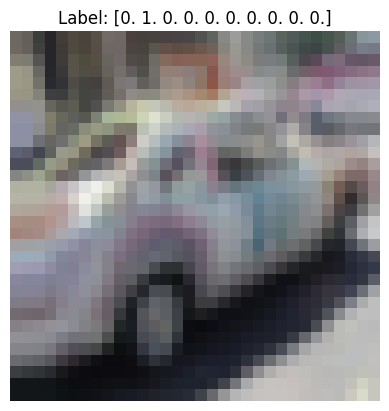

In [22]:
batch = datagen.flow(x_train, y_train, batch_size=1)
augmented_image, label = next(batch)

plt.imshow(augmented_image[0])
plt.title(f"Label: {label[0]}")
plt.axis('off')
plt.show()

In [ ]:
# Let's build a CNN using Keras' Sequential capabilities
model_1 = Sequential()

## 5x5 convolution with 2x2 stride and 32 filters
model_1.add(Conv2D(32, kernel_size = (5, 5), strides = (2,2), padding='same',
                 input_shape=x_train.shape[1:]))
model_1.add(Activation('relu'))

## Another 5x5 convolution with 2x2 stride and 32 filters
model_1.add(Conv2D(32, (5, 5), strides = (2,2), activation="relu")) # another way to define activation


## 2x2 max pooling reduces to 3 x 3 x 32
model_1.add(MaxPooling2D(pool_size=(2, 2)))
#model_1.add(Dropout(0.25))

## Flatten turns 3x3x32 into 288x1
model_1.add(Flatten())
model_1.add(Dense(512))
model_1.add(Activation('relu'))
#model_1.add(Dropout(0.5))
model_1.add(Dense(num_classes))
model_1.add(Activation('softmax'))

batch_size = 32

# Let's train the model using RMSprop
model_1.compile(loss='categorical_crossentropy',
                optimizer='rmsprop',
                metrics=['accuracy'])

# Fit the model on the batches generated by datagen.flow().
model_1.fit(
    datagen.flow(x_train, y_train, batch_size=batch_size),
    epochs=15,
    validation_data=(x_test, y_test)
)

Epoch 1/15


C:\Users\Karima Asaad\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 50ms/step - accuracy: 0.3188 - loss: 1.8596 - val_accuracy: 0.4642 - val_loss: 1.5356
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 51ms/step - accuracy: 0.4866 - loss: 1.4306 - val_accuracy: 0.5670 - val_loss: 1.2086
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 51ms/step - accuracy: 0.5393 - loss: 1.3027 - val_accuracy: 0.5439 - val_loss: 1.3573
Epoch 4/15
1516/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.5626 - loss: 1.2449

How does the performance compare with the non-augmented training?

## Exercise
### Your Turn

1. Experiment above with different settings of the data augmentation parameters.  Can you make the model do better?  Can you make it do worse?



In [28]:
datagen_2 = ImageDataGenerator(
    rotation_range=10,  
    width_shift_range=0.05, 
    height_shift_range=0.05,
    horizontal_flip=False,
    shear_range=0.05,
    zoom_range=0.1,
    fill_mode='nearest'
)

model_2.compile(loss='categorical_crossentropy',
                optimizer='adam',
                metrics=['accuracy'])

model_2.fit(
    datagen_2.flow(x_train, y_train, batch_size=batch_size),
    epochs=5,
    validation_data=(x_test, y_test)
)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 241s 153ms/step - accuracy: 0.3693 - loss: 1.7032 - val_accuracy: 0.6116 - val_loss: 1.0790
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 242s 155ms/step - accuracy: 0.6071 - loss: 1.1028 - val_accuracy: 0.6448 - val_loss: 1.0161
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 246s 158ms/step - accuracy: 0.6690 - loss: 0.9353 - val_accuracy: 0.7239 - val_loss: 0.8083
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 259s 166ms/step - accuracy: 0.7153 - loss: 0.8111 - val_accuracy: 0.7293 - val_loss: 0.7861
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 251s 161ms/step - accuracy: 0.7417 - loss: 0.7322 - val_accuracy: 0.7442 - val_loss: 0.7614
